<a href="https://colab.research.google.com/github/vridhichaudhary/Learning_ML/blob/main/practice1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Creating data that matches your worksheet modules
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Edward', 'Fiona', 'George', 'Elon Musk'],
    'Age': [25, 30, 35, 40, 45, 22, 55, 51],
    'Income': [50000, 60000, np.nan, 80000, 75000, np.nan, 90000, 10000000], # Missing values & Outlier
    'Education': ['B.Tech', 'M.Tech', 'PhD', 'B.Tech', np.nan, 'M.Tech', 'PhD', 'PhD'], # Missing value
    'Gender': ['Female', 'Male', 'Male', 'Female', 'Male', 'Female', 'Male', 'Male'], # Categorical
    'Loan_Status': ['Approved', 'Approved', 'Rejected', 'Approved', 'Rejected', 'Approved', 'Rejected', 'Approved']
}

### Step 1: Initial Data Setup and Exploration

**Imports:**
- `import pandas as pd`: Imported for data manipulation and analysis, especially with DataFrames.
- `import numpy as np`: Imported for numerical operations, particularly for handling `NaN` (Not a Number) values.
- `import warnings`: Imported to manage warning messages.
- `warnings.filterwarnings('ignore')`: Used to suppress warning messages for cleaner output.

**Features Used:**
- `pd.DataFrame()`: Creation of a DataFrame from a dictionary.
- `df.to_csv()`: Saving the DataFrame to a CSV file.
- `pd.read_csv()`: Loading data from a CSV file into a DataFrame.
- `df.info()`: Providing a concise summary of the DataFrame, including data types and non-null values.
- `df.isnull().sum()`: Calculating the number of missing values per column.


### Step 2: Handling Missing Values and Outliers (Initial Dataset)

**Imports:**
- No new imports in this step.

**Features Used:**
- `df.copy()`: Creating copies of DataFrames to apply different data cleaning strategies without modifying the original `df`.
- `df.dropna()`: Removing rows with any missing values.
- `df['Income'].median()`: Calculating the median of the 'Income' column.
- `df['Income'].fillna(value, inplace=True)`: Filling missing 'Income' values with the calculated median.
- `df['Income'].quantile(0.25)` and `df['Income'].quantile(0.75)`: Calculating the first and third quartiles for outlier detection.
- `IQR = Q3 - Q1`: Calculating the Interquartile Range.
- `lower_limit = Q1 - 1.5 * IQR`, `upper_limit = Q3 + 1.5 * IQR`: Defining the bounds for outlier detection using the IQR method.
- `df = df[(df['Income'] >= lower_limit) & (df['Income'] <= upper_limit)]`: Filtering the DataFrame to remove rows with 'Income' outliers.
- `df['Income'].clip(lower, upper)`: Capping outliers by replacing values outside the `lower` and `upper` bounds with the boundary values themselves.


### Step 3: Visualization and Categorical Data Handling (Initial Dataset)

**Imports:**
- `import matplotlib.pyplot as plt`: Imported for creating static, interactive, and animated visualizations.
- `import seaborn as sns`: Imported for statistical data visualization, built on Matplotlib.

**Features Used:**
- `plt.figure(figsize=(x,y))`: Setting the size of the plot figure.
- `sns.boxplot()`: Creating a box plot to visualize the distribution and potential outliers of the 'Income' column.
- `plt.show()`: Displaying the generated plot.
- `df.describe()`: Generating descriptive statistics of numerical columns.
- `df.describe(include='object')`: Generating descriptive statistics for object (categorical) columns.
- `pd.crosstab(df['Gender'], df['Education'])`: Creating a frequency table (cross-tabulation) between 'Gender' and 'Education'.
- `df['Education'].mode()[0]`: Finding the most frequent value (mode) in the 'Education' column for imputation.
- `df['Education'].fillna(df['Education'].mode()[0])`: Filling missing 'Education' values with its mode.
- `from sklearn.preprocessing import LabelEncoder`: Importing `LabelEncoder` for encoding categorical labels into numerical format.
- `le = LabelEncoder()`: Initializing the LabelEncoder.
- `df['Education'] = le.fit_transform(df['Education'])`: Applying Label Encoding to the 'Education' column.
- `pd.get_dummies(df, columns=['Gender'])`: Applying One-Hot Encoding to the 'Gender' column, converting categorical text into numerical columns (e.g., `Gender_Female`, `Gender_Male`).


### Step 4: Data Scaling (Initial Dataset)

**Imports:**
- `from sklearn.preprocessing import MinMaxScaler`: Importing `MinMaxScaler` for scaling features to a given range (typically 0 to 1).

**Features Used:**
- `scaler = MinMaxScaler()`: Initializing the MinMaxScaler.
- `df['Income'] = scaler.fit_transform(df[['Income']])`: Scaling the 'Income' column to a 0-1 range.
- `df['Age'] = scaler.fit_transform(df[['Age']])`: Scaling the 'Age' column to a 0-1 range.


### Step 5: Lab - Data Preprocessing and Model Training (New Dataset)

**Imports:**
- `import pandas as pd`, `import numpy as np`, `import matplotlib.pyplot as plt`: Re-imported for clarity in the new section.
- `from sklearn.preprocessing import StandardScaler`: Imported for standardizing features by removing the mean and scaling to unit variance.
- `from sklearn.model_selection import train_test_split`: Imported for splitting data into training and testing sets.

**Features Used (Data Cleaning and Preprocessing):**
- `df.head()`: Displaying the first few rows of the new DataFrame.
- `df.describe()`: Generating descriptive statistics.
- `df.isnull().sum()`: Counting null values.
- `df.duplicated().sum()`: Checking for duplicate rows.
- `df['Age'] = df['Age'].fillna(df['Age'].median())`: Imputing missing 'Age' values with the median.
- `df['Income'] = df['Income'].fillna(df['Income'].median())`: Imputing missing 'Income' values with the median.
- `df['Education'] = df['Education'].fillna(df['Education'].mode()[0])`: Imputing missing 'Education' values with the mode.
- `df = pd.get_dummies(df, columns=['Gender'])`: One-Hot Encoding for 'Gender'.
- `ed_map = {'High School':0,'Bachelor':1,'Master':2}`: Creating a custom mapping for 'Education' categories.
- `df['Education'] = df['Education'].map(ed_map)`: Applying the custom mapping to 'Education'.
- `def cap_outliers(series)`: A custom function to cap outliers using the IQR method.
- `df['Age'] = cap_outliers(df['Age'])`, `df['Income'] = cap_outliers(df['Income'])`: Applying the outlier capping function to 'Age' and 'Income'.

**Features Used (Model Preparation and Training):**
- `X = df.drop('Purchased', axis=1)`: Separating features (X) from the target variable (y).
- `y = df['Purchased']`: Defining the target variable.
- `X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)`: Splitting the dataset into training (80%) and testing (20%) sets.
- `scaler = StandardScaler()`: Initializing the StandardScaler.
- `X_train[['Age','Income']] = scaler.fit_transform(X_train[['Age','Income']])`: Fitting the scaler on training data and transforming 'Age' and 'Income'.
- `X_test[['Age','Income']] = scaler.transform(X_test[['Age','Income']])`: Transforming 'Age' and 'Income' in the test set using the *same* scaler fitted on training data.
- `from sklearn.linear_model import LogisticRegression`: Importing the `LogisticRegression` model.
- `model = LogisticRegression()`: Initializing the Logistic Regression model.
- `model.fit(X_train, y_train)`: Training the model on the training data.


### Step 6: Model Evaluation

**Imports:**
- `from sklearn.metrics import accuracy_score`: Importing `accuracy_score` for evaluating model performance.

**Features Used:**
- `y_pred = model.predict(X_test)`: Making predictions on the test set.
- `accuracy = accuracy_score(y_test, y_pred)`: Calculating the accuracy of the model by comparing true labels (`y_test`) with predicted labels (`y_pred`).


In [ ]:
df = pd.DataFrame(data)

In [ ]:
df.to_csv('loan_data.csv', index=False)

In [ ]:
df = pd.read_csv('loan_data.csv')

In [ ]:
df

,Name,Age,Income,Education,Gender,Loan_Status
0,Alice,25,50000.0,B.Tech,Female,Approved
1,Bob,30,60000.0,M.Tech,Male,Approved
2,Charlie,35,NaN,PhD,Male,Rejected
3,Diana,40,80000.0,B.Tech,Female,Approved
4,Edward,45,75000.0,NaN,Male,Rejected
5,Fiona,22,NaN,M.Tech,Female,Approved
6,George,55,90000.0,PhD,Male,Rejected
7,Elon Musk,51,10000000.0,PhD,Male,Approved


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         8 non-null      object 
 1   Age          8 non-null      int64  
 2   Income       6 non-null      float64
 3   Education    7 non-null      object 
 4   Gender       8 non-null      object 
 5   Loan_Status  8 non-null      object 
dtypes: float64(1), int64(1), object(4)
memory usage: 516.0+ bytes


In [ ]:
df.isnull().sum()

,0
Name,0
Age,0
Income,2
Education,1
Gender,0
Loan_Status,0


there are 3 strategies to fill null values
1. dropping the null values df.dropna()
2. filling with mean if data is fairly distributed
3. filling with median if outliers are present

In [ ]:
df1 = df.copy()

In [ ]:
df1 = df1.dropna()

In [ ]:

df2 = df.copy()

In [ ]:
df['Income'].fillna(df['Income'].median(),inplace = True)
df


,Name,Age,Income,Education,Gender,Loan_Status
0,Alice,25,50000.0,B.Tech,Female,Approved
1,Bob,30,60000.0,M.Tech,Male,Approved
2,Charlie,35,77500.0,PhD,Male,Rejected
3,Diana,40,80000.0,B.Tech,Female,Approved
4,Edward,45,75000.0,NaN,Male,Rejected
5,Fiona,22,77500.0,M.Tech,Female,Approved
6,George,55,90000.0,PhD,Male,Rejected
7,Elon Musk,51,10000000.0,PhD,Male,Approved


In [ ]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
df = df[(df['Income']>=lower_limit)&(df['Income']<=upper_limit)]
df

,Name,Age,Income,Education,Gender,Loan_Status
1,Bob,30,60000.0,M.Tech,Male,Approved
2,Charlie,35,77500.0,PhD,Male,Rejected
3,Diana,40,80000.0,B.Tech,Female,Approved
4,Edward,45,75000.0,NaN,Male,Rejected
5,Fiona,22,77500.0,M.Tech,Female,Approved
6,George,55,90000.0,PhD,Male,Rejected


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.describe()

,Age,Income
count,6.000000,6.000000
mean,37.833333,76666.666667
std,11.583034,9703.951085
min,22.000000,60000.000000
25%,31.250000,75625.000000
50%,37.500000,77500.000000
75%,43.750000,79375.000000
max,55.000000,90000.000000


In [ ]:
df.describe(include='object')

,Name,Education,Gender,Loan_Status
count,6,5,6,6
unique,6,3,2,2
top,Bob,M.Tech,Male,Approved
freq,1,2,4,3


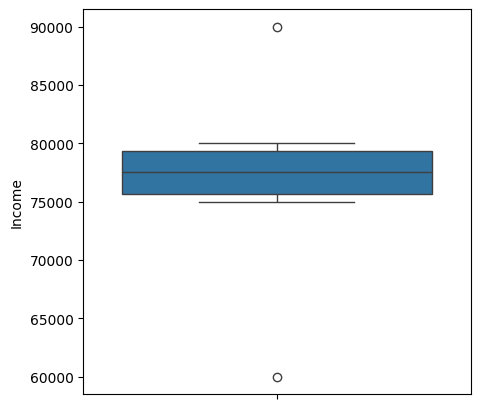

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(data=df['Income'])
plt.show()

In [ ]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
df_clean = df[(df['Income']>=lower)&(df['Income']<=upper)]
df_clean


,Name,Age,Income,Education,Gender,Loan_Status
2,Charlie,35,77500.0,PhD,Male,Rejected
3,Diana,40,80000.0,B.Tech,Female,Approved
4,Edward,45,75000.0,NaN,Male,Rejected
5,Fiona,22,77500.0,M.Tech,Female,Approved


In [ ]:
df['Income'] = df['Income'].clip(lower,upper)


In [ ]:
df

,Name,Age,Income,Education,Gender,Loan_Status
1,Bob,30,70000.0,M.Tech,Male,Approved
2,Charlie,35,77500.0,PhD,Male,Rejected
3,Diana,40,80000.0,B.Tech,Female,Approved
4,Edward,45,75000.0,NaN,Male,Rejected
5,Fiona,22,77500.0,M.Tech,Female,Approved
6,George,55,85000.0,PhD,Male,Rejected


In [ ]:
median_val = df['Income'].median()
df['Income'] = df['Income'].fillna(median_val)

<Axes: ylabel='Income'>

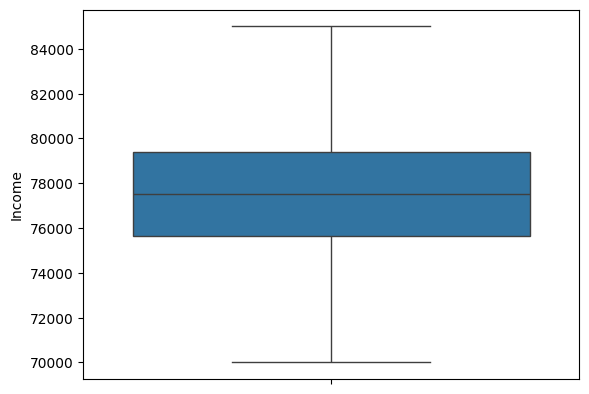

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df['Income'])


In [ ]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

df = df[(df['Income']>=lower)&(df['Income']<=upper)]
df

,Name,Age,Income,Education,Gender,Loan_Status
1,Bob,30,70000.0,M.Tech,Male,Approved
2,Charlie,35,77500.0,PhD,Male,Rejected
3,Diana,40,80000.0,B.Tech,Female,Approved
4,Edward,45,75000.0,NaN,Male,Rejected
5,Fiona,22,77500.0,M.Tech,Female,Approved
6,George,55,85000.0,PhD,Male,Rejected


In [ ]:
pd.crosstab(df['Gender'],df['Education'])

Education,B.Tech,M.Tech,PhD
Gender,,,
Female,1,1,0
Male,0,1,2


In [ ]:
df['Education'].mode()[0]

'M.Tech'

In [ ]:
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Education'] = le.fit_transform(df['Education'])
df.head()

,Name,Age,Income,Education,Gender,Loan_Status
1,Bob,30,70000.0,1,Male,Approved
2,Charlie,35,77500.0,2,Male,Rejected
3,Diana,40,80000.0,0,Female,Approved
4,Edward,45,75000.0,1,Male,Rejected
5,Fiona,22,77500.0,1,Female,Approved


In [ ]:
df = pd.get_dummies(df,columns=['Gender'])
df.head()

,Name,Age,Income,Education,Loan_Status,Gender_Female,Gender_Male
1,Bob,30,70000.0,1,Approved,False,True
2,Charlie,35,77500.0,2,Rejected,False,True
3,Diana,40,80000.0,0,Approved,True,False
4,Edward,45,75000.0,1,Rejected,False,True
5,Fiona,22,77500.0,1,Approved,True,False


In [ ]:
data = {
    "Age" : np.random.randint(20,60,50),
    "Income" : np.random.randint(20000, 80000 , 50)
}

df = pd.DataFrame(data)
df

,Age,Income
0,25,34738
1,54,36753
2,29,63330
3,50,67481
4,52,37305
5,59,52674
6,30,38098
7,32,64467
8,32,27948
9,21,30850


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df['Income'] = scaler.fit_transform(df[['Income']])
df['Age'] = scaler.fit_transform(df[['Age']])
df

,Age,Income
0,0.128205,0.235463
1,0.871795,0.269683
2,0.230769,0.721028
3,0.769231,0.791522
4,0.820513,0.279057
5,1.000000,0.540062
6,0.256410,0.292524
7,0.307692,0.740337
8,0.307692,0.120151
9,0.025641,0.169435


#LAB



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
data = {
    'Age': [25, 30, np.nan, 45, 50, 22, 35, 40, 200, 28, 33, np.nan, 55, 60, 180, 70, 42, 38, 29, 31],
    'Income': [50000, 60000, 70000, np.nan, 90000, 40000, 55000, 65000, 1000000, 52000, 61000, 72000, np.nan, 85000, 30000, 95000, 58000, 63000, 54000, 62000],
    'Gender': ['Male', 'Female', 'Others', 'Female', 'Male', 'Others', 'Male', 'Female', 'Male', 'Female', 'Others', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'Education': ['Bachelor', np.nan, 'High School', 'Bachelor', 'Master', 'High School', 'Bachelor', 'Master', 'High School', 'Bachelor', 'Master', 'High School', 'Bachelor', 'Master', 'High School', 'Bachelor', 'Master', 'High School', 'Bachelor', 'Master'],
    'Purchased': [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0]
}

df = pd.DataFrame(data)

In [ ]:
df.head()

,Age,Income,Gender,Education,Purchased
0,25.0,50000.0,Male,Bachelor,0
1,30.0,60000.0,Female,NaN,0
2,NaN,70000.0,Others,High School,0
3,45.0,NaN,Female,Bachelor,1
4,50.0,90000.0,Male,Master,0


In [ ]:
df.describe()

,Age,Income,Purchased
count,18.000000,18.000000,20.000000
mean,56.277778,114555.555556,0.200000
std,50.385345,221570.390415,0.410391
min,22.000000,30000.000000,0.000000
25%,30.250000,54250.000000,0.000000
50%,39.000000,61500.000000,0.000000
75%,53.750000,71500.000000,0.000000
max,200.000000,1000000.000000,1.000000


In [ ]:
df.isnull().sum()

,0
Age,2
Income,2
Gender,0
Education,1
Purchased,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Income'] = df['Income'].fillna(df['Income'].median())
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])

In [ ]:
df = pd.get_dummies(df,columns=['Gender'])

In [ ]:
ed_map = {'High School':0,'Bachelor':1,'Master':2}
df['Education'] = df['Education'].map(ed_map)

In [ ]:
df

,Age,Income,Education,Purchased,Gender_Female,Gender_Male,Gender_Others
0,25.0,50000.0,1,0,False,True,False
1,30.0,60000.0,1,0,True,False,False
2,39.0,70000.0,0,0,False,False,True
3,45.0,61500.0,1,1,True,False,False
4,50.0,90000.0,2,0,False,True,False
5,22.0,40000.0,0,0,False,False,True
6,35.0,55000.0,1,0,False,True,False
7,40.0,65000.0,2,1,True,False,False
8,200.0,1000000.0,0,0,False,True,False
9,28.0,52000.0,1,0,True,False,False


<Axes: ylabel='Age'>

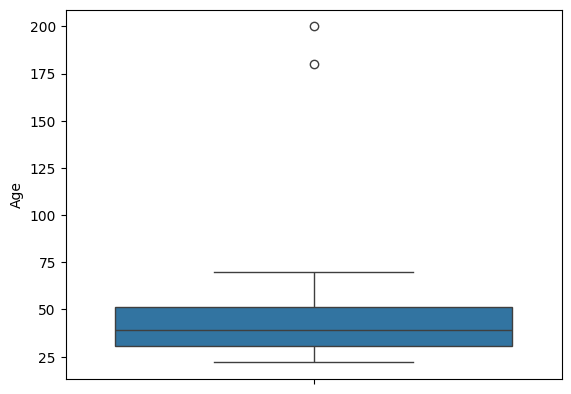

In [ ]:
sns.boxplot(data=df['Age'])

In [ ]:
def cap_outliers(series):
  Q1 = series.quantile(0.25)
  Q3 = series.quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  return np.clip(series,lower_bound,upper_bound)

df['Age'] = cap_outliers(df['Age'])
df['Income'] = cap_outliers(df['Income'])

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('Purchased',axis=1)
y = df['Purchased']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train[['Age','Income']] = scaler.fit_transform(X_train[['Age','Income']])
X_test[['Age','Income']] = scaler.transform(X_test[['Age','Income']])
X_train

,Age,Income,Education,Gender_Female,Gender_Male,Gender_Others
8,2.187044,1.913782,0,False,True,False
5,-1.312227,-1.442846,0,False,False,True
11,-0.320767,0.541673,0,True,False,False
3,0.029161,-0.109497,1,True,False,False
18,-0.903978,-0.574619,1,False,True,False
16,-0.145803,-0.326554,2,False,True,False
13,0.903978,1.347884,2,True,False,False
2,-0.320767,0.417641,0,False,False,True
9,-0.962300,-0.698652,1,True,False,False
19,-0.787336,-0.078489,2,True,False,False


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
accuracy

0.75